## 01 — EDA: raw images + ground truth overlays

This notebook:
- loads one training FOV’s Epi `.dax`
- visualizes DAPI + polyT for a single z-plane
- overlays ground-truth boundaries (z2) on the DAPI image

### Data path
Set `MERFISH_DATA_ROOT` (recommended for Modal mounts). Otherwise we default to `/scratch/pl2820/competition`.


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make repo imports work when running from notebooks/
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.io import load_fov_images

# Prefer local ./data when present; override via MERFISH_DATA_ROOT.
DEFAULT_DATA_ROOT = os.path.join(REPO_ROOT, 'data')
DATA_ROOT = os.environ.get('MERFISH_DATA_ROOT', DEFAULT_DATA_ROOT)
FOV = os.environ.get('MERFISH_FOV', 'FOV_001')
Z = int(os.environ.get('MERFISH_Z', '2'))

train_dir = os.path.join(DATA_ROOT, 'train')
fov_dir = f"{train_dir}/{FOV}" if os.path.isdir(train_dir) else DATA_ROOT

dapi, polyt = load_fov_images(fov_dir, fov=FOV)
print('Loaded', FOV, 'from', fov_dir, '| dapi', dapi.shape, 'polyt', polyt.shape)


Loaded FOV_001 from /Users/chetangoel/Desktop/Repositories/cell-segmentation-assignment/data | dapi (5, 2048, 2048) polyt (5, 2048, 2048)


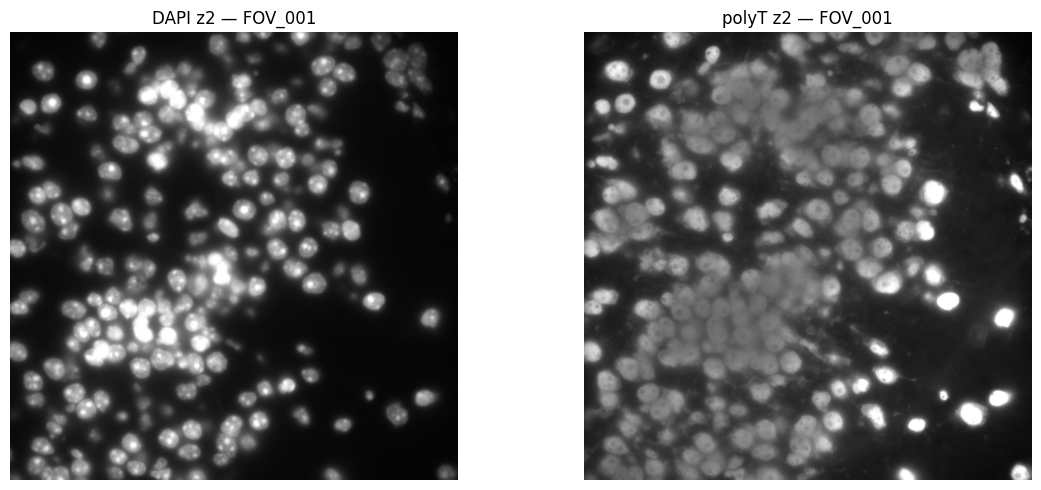

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(dapi[Z], cmap='gray', vmin=0, vmax=np.percentile(dapi[Z], 99))
axes[0].set_title(f'DAPI z{Z} — {FOV}')
axes[0].axis('off')

axes[1].imshow(polyt[Z], cmap='gray', vmin=0, vmax=np.percentile(polyt[Z], 99))
axes[1].set_title(f'polyT z{Z} — {FOV}')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [3]:
import os
import pandas as pd

from src.coords import parse_boundary_polygon

meta_path = os.path.join(DATA_ROOT, 'reference', 'fov_metadata.csv')
boundaries_path = os.path.join(DATA_ROOT, 'train', 'ground_truth', 'cell_boundaries_train.csv')

if (not os.path.exists(meta_path)) or (not os.path.exists(boundaries_path)):
    print('Skipping GT overlay: missing competition metadata/GT files.')
    print('Expected:')
    print(' -', meta_path)
    print(' -', boundaries_path)
    print('\nTip: set MERFISH_DATA_ROOT to the full competition dataset root to enable overlays.')
else:
    meta = pd.read_csv(meta_path).set_index('fov')
    fov_x = float(meta.loc[FOV, 'fov_x'])
    fov_y = float(meta.loc[FOV, 'fov_y'])
    pixel_size = float(meta.loc[FOV, 'pixel_size'])

    cells = pd.read_csv(boundaries_path, index_col=0)
    fov_cells = cells[cells.index.str.startswith(FOV)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(dapi[Z], cmap='gray', vmin=0, vmax=np.percentile(dapi[Z], 99))

    boundary_x = f'boundaryX_z{Z}'
    boundary_y = f'boundaryY_z{Z}'

    n_plotted = 0
    for _cell_id, row in fov_cells.iterrows():
        poly = parse_boundary_polygon(str(row.get(boundary_x, '')), str(row.get(boundary_y, '')))
        if poly is None:
            continue
        xs_um = poly.exterior.xy[0]
        ys_um = poly.exterior.xy[1]
        xs_px = [(x - fov_x) / pixel_size for x in xs_um]
        ys_px = [(y - fov_y) / pixel_size for y in ys_um]
        ax.plot(xs_px, ys_px, 'c-', linewidth=0.5, alpha=0.8)
        n_plotted += 1

    ax.set_title(f"{FOV} — {len(fov_cells)} GT cells (plotted {n_plotted})")
    ax.axis('off')
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/chetangoel/Desktop/Repositories/cell-segmentation-assignment/data/reference/fov_metadata.csv'

In [ ]:
import os

spots_path = os.path.join(DATA_ROOT, 'train', 'ground_truth', 'spots_train.csv')

if not os.path.exists(spots_path):
    print('Skipping spots summary: missing', spots_path)
else:
    spots_train = pd.read_csv(spots_path)
    print('Spots per FOV:')
    print(spots_train.groupby('fov').size().describe())
    print(f"\n{FOV} spots: {len(spots_train[spots_train['fov'] == FOV])}")
    if 'fov_cells' in globals():
        print(f"{FOV} GT cells: {len(fov_cells)}")
